# MarketScout: Система прогнозування цін на авто
Цей ноутбук призначений для побудови моделі машинного навчання, яка прогнозує вартість автомобілів на основі їхніх характеристик.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
import joblib

# FIX: Added random seed for full reproducibility across all operations
RANDOM_SEED = 42
CURRENT_YEAR = 2026

In [2]:
# Завантаження датасету
data = pd.read_csv("../data/cars_dataset.csv")
df = data.copy()

print(f"Розмір датасету: {df.shape[0]} рядків, {df.shape[1]} колонок")
print(f"Пропуски:\n{df.isnull().sum()}")
display(df.head(3))

Розмір датасету: 18893 рядків, 9 колонок
Пропуски:
ID             0
Mark          88
Model        854
Year           0
Price_USD      0
Mileage        0
Engine         0
Fuel           0
Gearbox        0
dtype: int64


,ID,Mark,Model,Year,Price_USD,Mileage,Engine,Fuel,Gearbox
0,2059468,Opel,Omega,1990,1900,300,0,"Бензин, 1.8 л.",Ручна / Механіка
1,39346065,Mercedes-Benz,eVito,2021,27800,257,0,Електро,Автомат
2,38511410,Volkswagen,E-Tharu,2020,18000,31,0,Електро,Автомат


## Очищення та підготовка даних

In [3]:
# 1. Базове очищення
# FIX: Price_USD > 0 тут надлишковий — далі є жорсткий фільтр >= 1000.
# Залишаємо для видалення явно некоректних нульових записів.
df = df.drop(columns=['ID', 'Engine'], errors='ignore')
df = df[df['Price_USD'] > 0].copy()
print(f"Після базового очищення: {len(df)} рядків")

Після базового очищення: 18617 рядків


In [4]:
# 2. Створення ознаки Age та фільтрація дуже старих авто
# FIX: Використовуємо константу CURRENT_YEAR замість хардкоду
df['Age'] = CURRENT_YEAR - df['Year']

# FIX: Додаємо також фільтр Age >= 0 — захист від авто з роком > поточного
df = df[(df['Age'] >= 0) & (df['Age'] <= 46)].copy()  # Відкидаємо авто до 1980 року
print(f"Після фільтрації за віком: {len(df)} рядків")

Після фільтрації за віком: 18551 рядків


In [5]:
# 3. Розбиття Fuel на Fuel_Type та Engine_Capacity
split_data = df['Fuel'].str.split(', ', expand=True)
df['Fuel_Type'] = split_data[0]

# FIX: Використовуємо regex=False у str.replace для уникнення FutureWarning
df['Engine_Capacity'] = pd.to_numeric(
    split_data[1].str.replace(' л.', '', regex=False),
    errors='coerce'
).fillna(0)

df = df.drop(columns=['Fuel'], errors='ignore')
print(f"Унікальні типи пального: {df['Fuel_Type'].unique()}")

Унікальні типи пального: ['Бензин' 'Електро' 'Дизель' 'Гібрид (HEV)' 'Газ пропан-бутан / Бензин'
 'Гібрид (MHEV)' 'Гібрид (PHEV)' 'Не вказано' '1.1 л.' '2 л.' '2.5 л.'
 '1.8 л.' 'Газ' '2.4 л.' '3.5 л.' '5.5 л.' '2.7 л.' '1.7 л.' '3 л.'
 '1.6 л.' '2.8 л.' '4.7 л.' '4.2 л.' '0.25 л.' '1.5 л.' '5 л.' '2.2 л.'
 '1.9 л.' '1.4 л.' '1.3 л.' '5.7 л.' '1.34 л.' '4 л.' '3.7 л.' '3.6 л.'
 'Газ метан / Бензин' '4.6 л.' '99.99 л.' '1.2 л.' '0.12 л.' '8 л.' '1 л.'
 '0.11 л.' '0.8 л.' '150 см³' '3.2 л.' '1.98 л.' '5.2 л.' '2.3 л.'
 '3.8 л.' '2.15 л.' '4.4 л.' '5.3 л.' '0.65 л.' '2.45 л.' '3.3 л.'
 '14.8 л.' '1.15 л.' '1.61 л.' '0.7 л.' '1.97 л.' '2.1 л.' '6 л.' '0.6 л.'
 '2.39 л.' '10 л.' '1.99 л.' '1100 см³']


In [6]:
# 4. Створення нових ознак
df['Km_per_Year'] = df['Mileage'] / (df['Age'] + 1)
df['is_EV'] = (df['Fuel_Type'] == 'Електро').astype(int)
df['is_suspicious_mileage'] = ((df['Age'] > 10) & (df['Mileage'] < 50)).astype(int)

# FIX: Додаємо корисну ознаку — чи є авто новим (до 3 років)
df['is_new'] = (df['Age'] <= 3).astype(int)

print(f"Підозрілий пробіг: {df['is_suspicious_mileage'].sum()} авто")
print(f"Електромобілі: {df['is_EV'].sum()} авто")

Підозрілий пробіг: 1413 авто
Електромобілі: 1458 авто


In [7]:
# 5. Заповнення пропусків
# FIX: Також заповнюємо Gearbox на випадок пропусків
df['Mark'] = df['Mark'].fillna('Other')
df['Model'] = df['Model'].fillna('Other')
df['Gearbox'] = df['Gearbox'].fillna('Unknown')

print(f"Пропуски після заповнення:\n{df[['Mark','Model','Gearbox','Fuel_Type']].isnull().sum()}")

Пропуски після заповнення:
Mark         0
Model        0
Gearbox      0
Fuel_Type    0
dtype: int64


In [8]:
# 6. Жорсткі бізнес-фільтри (застосовуємо до всього датасету)
before = len(df)
df = df[
    (df['Price_USD'] >= 1000) &
    (df['Price_USD'] <= 250000) &
    (df['Engine_Capacity'] <= 10)
].copy()
print(f"Відфільтровано {before - len(df)} записів. Залишилось: {len(df)}")

Відфільтровано 367 записів. Залишилось: 18184


## Підготовка до моделювання

In [9]:
# FIX: Додано 'is_new' до списку ознак
features = [
    'Mark', 'Model', 'Mileage', 'Gearbox', 'Age',
    'Fuel_Type', 'Engine_Capacity', 'Km_per_Year',
    'is_EV', 'is_suspicious_mileage', 'is_new'
]
cat_features = ['Mark', 'Model', 'Gearbox', 'Fuel_Type']

X = df[features]
y = df['Price_USD']

print(f"Ознаки: {features}")
print(f"Розмір X: {X.shape}")

Ознаки: ['Mark', 'Model', 'Mileage', 'Gearbox', 'Age', 'Fuel_Type', 'Engine_Capacity', 'Km_per_Year', 'is_EV', 'is_suspicious_mileage', 'is_new']
Розмір X: (18184, 11)


In [10]:
# FIX: Логарифмування цілі робиться ДО split — щоб y_log і y були синхронні
y_log = np.log1p(y)

# Розбиття на train та test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.2, random_state=RANDOM_SEED
)

X_train = X_train.copy()
X_test = X_test.copy()

print(f"Train: {len(X_train)}, Test: {len(X_test)}")

Train: 14547, Test: 3637


In [11]:
# 1. Фільтрація рідкісних марок/моделей
# FIX: Поріг 5 замінений на більш обґрунтований поріг 10 для кращої генералізації
MIN_COUNT = 10
mark_counts = X_train['Mark'].value_counts()
model_counts = X_train['Model'].value_counts()

valid_marks = mark_counts[mark_counts >= MIN_COUNT].index
valid_models = model_counts[model_counts >= MIN_COUNT].index

print(f"Унікальних марок (>= {MIN_COUNT}): {len(valid_marks)}")
print(f"Унікальних моделей (>= {MIN_COUNT}): {len(valid_models)}")

Унікальних марок (>= 10): 58
Унікальних моделей (>= 10): 272


In [12]:
# Заміна рідкісних значень на 'Other'
for col, valid in [('Mark', valid_marks), ('Model', valid_models)]:
    X_train[col] = np.where(X_train[col].isin(valid), X_train[col], 'Other')
    X_test[col] = np.where(X_test[col].isin(valid), X_test[col], 'Other')

In [13]:
# 2. Видалення статистичних викидів (Outliers) за допомогою IQR
# ВАЖЛИВО: IQR застосовується тільки до train — test залишається незайманим
Q1 = np.percentile(y_train, 25)
Q3 = np.percentile(y_train, 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# FIX: Виводимо межі у зрозумілих доларах (expm1 -> зворотне перетворення)
print(f"Межі IQR (лог): [{lower_bound:.4f}, {upper_bound:.4f}]")
print(f"Межі IQR (USD): [{np.expm1(lower_bound):.0f}, {np.expm1(upper_bound):.0f}]")

Межі IQR (лог): [7.2308, 11.6524]
Межі IQR (USD): [1380, 114963]


In [14]:
# Залишаємо лише ті рядки в train, які входять у межі
before = len(X_train)
train_mask = (y_train >= lower_bound) & (y_train <= upper_bound)
X_train = X_train[train_mask]
y_train = y_train[train_mask]
print(f"Видалено {before - len(X_train)} викидів з train. Залишилось: {len(X_train)}")

Видалено 271 викидів з train. Залишилось: 14276


## Навчання моделі CatBoost

In [15]:
# FIX: Додано loss_function='MAE' — узгоджено з eval_metric для стабільнішого навчання
# FIX: random_seed -> random_state (сучасний параметр CatBoost)
model = CatBoostRegressor(
    iterations=3000,
    learning_rate=0.05,
    depth=8,               # FIX: Зменшено з 10 до 8 — менше перенавчання
    l2_leaf_reg=5,         # FIX: Збільшено регуляризацію для кращої генералізації
    loss_function='MAE',   # FIX: явно задаємо цільову функцію
    eval_metric='MAE',
    random_seed=RANDOM_SEED,
    verbose=500,
    one_hot_max_size=2000
)

print("Починаємо навчання моделі...")
model.fit(
    X_train, y_train,
    cat_features=cat_features,
    eval_set=(X_test, y_test),
    early_stopping_rounds=150
)
print(f"Найкраща ітерація: {model.best_iteration_}")

Починаємо навчання моделі...
0:	learn: 0.6203369	test: 0.6554794	best: 0.6554794 (0)	total: 155ms	remaining: 7m 44s
500:	learn: 0.1826128	test: 0.2054503	best: 0.2054503 (500)	total: 2.42s	remaining: 12.1s
1000:	learn: 0.1596785	test: 0.1913437	best: 0.1913437 (1000)	total: 7.01s	remaining: 14s
1500:	learn: 0.1452442	test: 0.1857561	best: 0.1857561 (1500)	total: 9.19s	remaining: 9.18s
2000:	learn: 0.1349226	test: 0.1827776	best: 0.1827776 (2000)	total: 11.2s	remaining: 5.61s
2500:	learn: 0.1266708	test: 0.1807091	best: 0.1806726 (2481)	total: 13.3s	remaining: 2.66s
2999:	learn: 0.1198417	test: 0.1796483	best: 0.1796408 (2976)	total: 15.4s	remaining: 0us

bestTest = 0.1796408107
bestIteration = 2976

Shrink model to first 2977 iterations.
Найкраща ітерація: 2976


In [16]:
# Отримуємо прогнози
y_pred_log = model.predict(X_test)

# Повертаємо ціни у звичайні долари за допомогою експоненти
y_pred = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test)

mae = mean_absolute_error(y_test_real, y_pred)
mape = mean_absolute_percentage_error(y_test_real, y_pred) * 100
r2 = r2_score(y_test_real, y_pred)

print(f"\n--- ФІНАЛЬНІ РЕЗУЛЬТАТИ ---")
print(f"MAE  (Середня похибка в доларах): {mae:.2f} USD")
print(f"MAPE (Середня похибка у відсотках): {mape:.2f}%")
print(f"R²   (Коефіцієнт детермінації): {r2:.4f}")
print(f"\nМедіанна AE: {np.median(np.abs(y_test_real.values - y_pred)):.2f} USD")


--- ФІНАЛЬНІ РЕЗУЛЬТАТИ ---
MAE  (Середня похибка в доларах): 3128.56 USD
MAPE (Середня похибка у відсотках): 20.97%
R²   (Коефіцієнт детермінації): 0.8528

Медіанна AE: 1304.96 USD


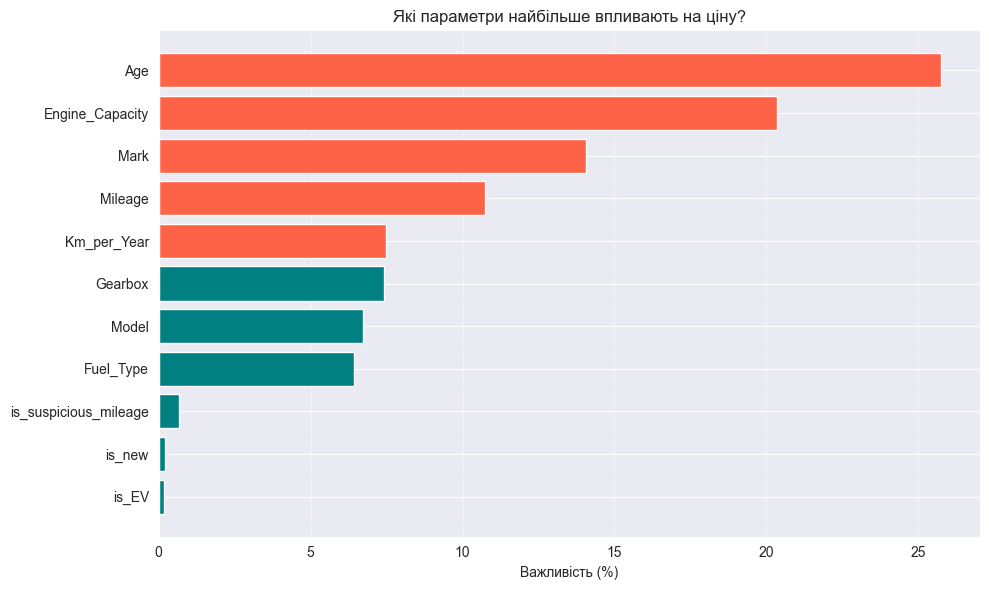

In [17]:
# FIX: Використовуємо правильний список ознак (включаючи is_new)
importance = model.get_feature_importance()
feat_imp = pd.Series(importance, index=features).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
colors = ['tomato' if v > feat_imp.median() else 'teal' for v in feat_imp.values]
plt.barh(feat_imp.index, feat_imp.values, color=colors)
plt.xlabel('Важливість (%)')
plt.title('Які параметри найбільше впливають на ціну?')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

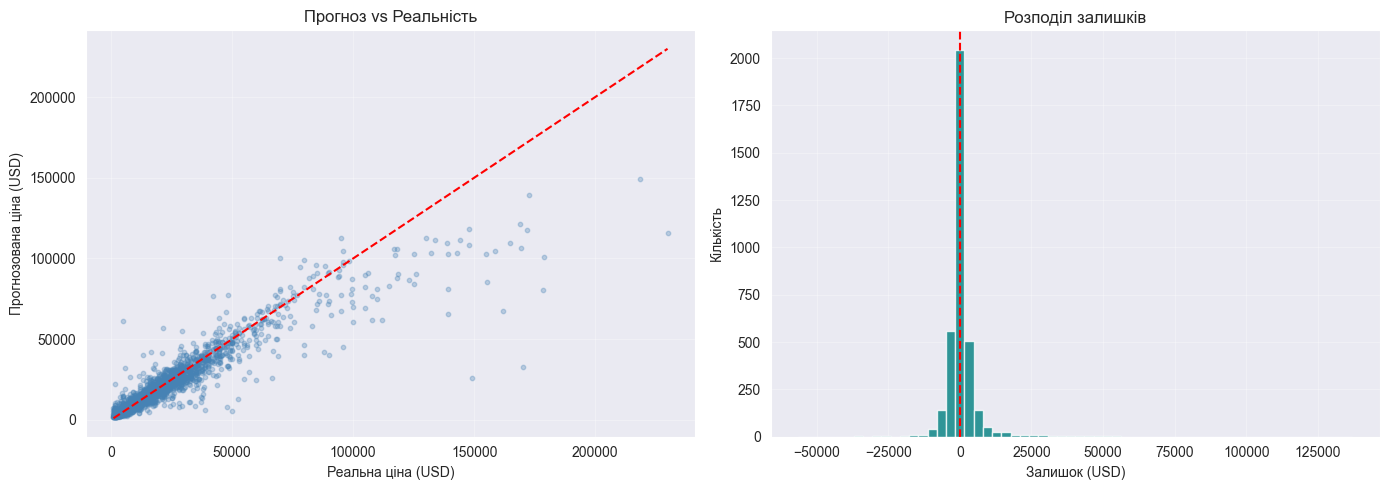

In [18]:
# FIX: Додано графік залишків — важливий для діагностики якості моделі
residuals = y_test_real.values - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Прогноз vs Реальна ціна
axes[0].scatter(y_test_real, y_pred, alpha=0.3, s=10, color='steelblue')
axes[0].plot(
    [y_test_real.min(), y_test_real.max()],
    [y_test_real.min(), y_test_real.max()],
    'r--', linewidth=1.5
)
axes[0].set_xlabel('Реальна ціна (USD)')
axes[0].set_ylabel('Прогнозована ціна (USD)')
axes[0].set_title('Прогноз vs Реальність')
axes[0].grid(True, alpha=0.3)

# Розподіл залишків
axes[1].hist(residuals, bins=60, color='teal', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Залишок (USD)')
axes[1].set_ylabel('Кількість')
axes[1].set_title('Розподіл залишків')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
# FIX: Збереження моделі (раніше було відсутнє, хоча joblib імпортували)
model.save_model("catboost_car_price.cbm")
print("Модель збережено у catboost_car_price.cbm")

Модель збережено у catboost_car_price.cbm
